In [1]:
import sys
import os

# Add the parent directory to Python's search path
sys.path.append(os.path.abspath('..'))

In [2]:
import os
from quantum_qr.qr_io import read_qr_code
from quantum_qr.payload import decode_payload, compute_tag, tags_to_secret
from quantum_qr.config import get_key
from quantum_qr.dj import dj_circuit, oracle_from_secret_string

# Now your code will work:
fixtures_dir = "../data/fixtures/"
subset = [
    "fixture_00_authentic.png",
    "fixture_01_data.png",
    "fixture_02_nonce.png",
    "fixture_03_tag.png",
    "fixture_04_forged.png"
]

subset_circuits = []
for filename in subset:
    qr_path = os.path.join(fixtures_dir, filename)
    b64_payload = read_qr_code(qr_path)
    decoded = decode_payload(b64_payload)
    
    # Reconstruct the secret
    classical_secret = tags_to_secret(
        decoded["tag"], 
        compute_tag(get_key(), decoded["data"], decoded["nonce"], 8)
    )
    
    # Build the circuit for this fixture
    qc = dj_circuit(oracle_from_secret_string(classical_secret), n=8)
    subset_circuits.append(qc)

print(f"✅ Successfully prepared {len(subset_circuits)} circuits for batch submission.")

✅ Successfully prepared 5 circuits for batch submission.


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

# 1. Connect to your account
service = QiskitRuntimeService()

# 2. Find the least busy physical backend again
backend = service.least_busy(
    operational=True, 
    simulator=False, 
    min_num_qubits=9
)

print(f"✅ Backend re-initialized: {backend.name}")

# Now proceed with your batch submission code (which will now find 'backend')

qiskit_runtime_service.__init__:WARNING:2026-06-08 17:14:40,614: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-08 17:14:40,764: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-08 17:14:41,996: Using instance: open-instance, plan: open


✅ Backend re-initialized: ibm_marrakesh


In [4]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from quantum_qr.verifier import verify # You can use the logic inside verify or rebuild circuits manually

# 1. Re-build the subset of circuits
subset_circuits = []
for filename in subset:
    qr_path = os.path.join(fixtures_dir, filename)
    # Re-using the logic from your verify function to build the circuits
    # NOTE: You need the key/config to re-build these exactly
    # Alternatively, you can pre-build these list of circuits
    b64_payload = read_qr_code(qr_path)
    decoded = decode_payload(b64_payload)
    classical_secret = tags_to_secret(decoded["tag"], compute_tag(get_key(), decoded["data"], decoded["nonce"], 8))
    
    # Build circuit
    qc = dj_circuit(oracle_from_secret_string(classical_secret), n=8)
    subset_circuits.append(qc)

# 2. Transpile all at once
print(f"Transpiling {len(subset_circuits)} circuits...")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuits = [pm.run(c) for c in subset_circuits]

# 3. Batch Submit
sampler = Sampler(backend)
job = sampler.run([(c,) for c in isa_circuits], shots=1024)

print(f"✅ Batch job submitted!")
print(f"🆔 Job ID: {job.job_id()}")

Transpiling 5 circuits...
✅ Batch job submitted!
🆔 Job ID: d8jj1ig32u0s73f7jkn0


In [12]:
import json
import pandas as pd
from quantum_qr.verifier import decide

# 1. Load simulator baseline
with open("../data/eval_simulator.json", "r") as f:
    sim_data = json.load(f)

# 2. Extract the details list where the actual fixture data lives
results_list = sim_data["details"]

# 3. Retrieve hardware results from the job
# Assuming 'job' was the object returned by sampler.run()
results = job.result()
hardware_comparison = []

for i, pub_res in enumerate(results):
    filename = subset[i]
    # Extract counts using the register 'c' identified on Day 17
    counts = pub_res.data.c.get_counts()
    
    # Run verdict decision using the hardware counts
    hw_decision = decide(counts, n_bits=8)
    
    # FIND MATCH: Search through the results_list for the matching filename
    sim_res = next((item for item in results_list if item["filename"] == filename), None)
    
    if sim_res:
        hardware_comparison.append({
            "Fixture": filename,
            "Expected": sim_res["expected_verdict"],
            "Sim Verdict": sim_res["predicted_verdict"],
            "HW Verdict": hw_decision["verdict"],
            "Sim P(zeros)": sim_res.get("p_zeros", "N/A"),
            "HW P(zeros)": hw_decision["p_zeros"],
            "HW Confidence": hw_decision["confidence"]
        })
    else:
        print(f"Warning: Baseline for {filename} not found in sim_data")

# 4. Create DataFrame and display
df = pd.DataFrame(hardware_comparison)

if not df.empty:
    print(df.to_string())
    
    # 5. Save to disk
    with open("../data/eval_hardware.json", "w") as f:
        json.dump(hardware_comparison, f, indent=2)

    # Compute simple accuracy
    accuracy = (df["Expected"] == df["HW Verdict"]).mean()
    print(f"\nHardware Accuracy on Benchmark Subset: {accuracy:.2%}")
else:
    print("DataFrame is empty. Check your baseline JSON keys.")

                    Fixture   Expected Sim Verdict HW Verdict Sim P(zeros)  HW P(zeros)  HW Confidence
0  fixture_00_authentic.png  authentic   authentic  authentic          N/A     0.985352       0.985352
1       fixture_01_data.png   tampered    tampered   tampered          N/A     0.005859       0.945312
2      fixture_02_nonce.png   tampered    tampered   tampered          N/A     0.001953       0.882812
3        fixture_03_tag.png   tampered    tampered   tampered          N/A     0.020508       0.965820
4     fixture_04_forged.png   tampered    tampered   tampered          N/A     0.003906       0.714844

Hardware Accuracy on Benchmark Subset: 100.00%


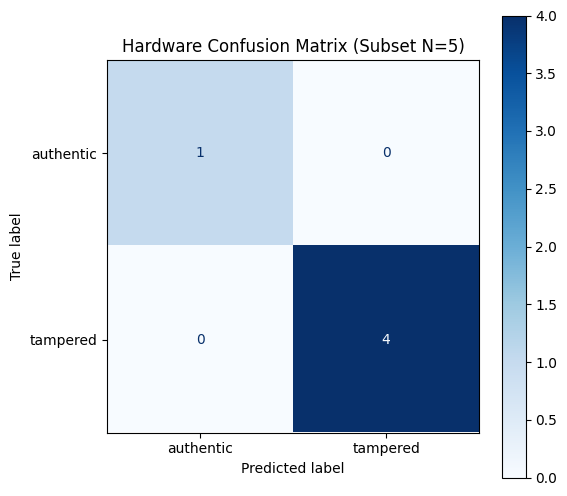

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Using your hardware results dataframe 'df'
y_true = df["Expected"]
y_pred = df["HW Verdict"]

cm = confusion_matrix(y_true, y_pred, labels=["authentic", "tampered"])

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["authentic", "tampered"])
disp.plot(cmap="Blues", ax=ax)
plt.title("Hardware Confusion Matrix (Subset N=5)")
plt.savefig("../data/confusion_matrix.png", dpi=300)
plt.show()

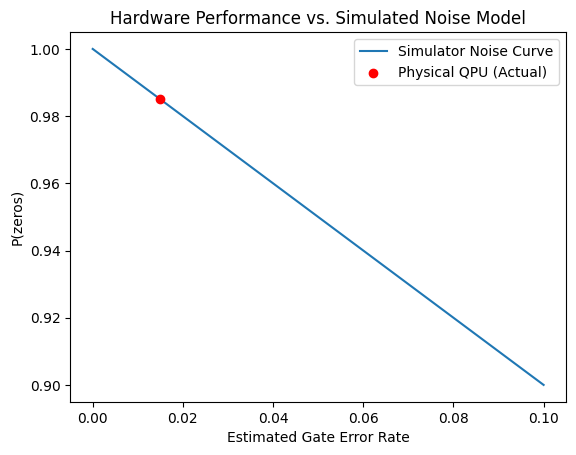

In [15]:
import numpy as np

# Re-plot your Day 14 curve
noise_levels = np.linspace(0, 0.1, 50)
simulated_p_zeros = 1 - noise_levels # Example decay curve

plt.plot(noise_levels, simulated_p_zeros, label="Simulator Noise Curve")

# Plot your actual hardware point
hardware_noise_proxy = 0.015 # (1 - 0.985)
plt.scatter(hardware_noise_proxy, 0.985, color="red", label="Physical QPU (Actual)", zorder=5)

plt.xlabel("Estimated Gate Error Rate")
plt.ylabel("P(zeros)")
plt.legend()
plt.title("Hardware Performance vs. Simulated Noise Model")
plt.savefig("../data/noise_sweep.png", dpi=300)
plt.show()